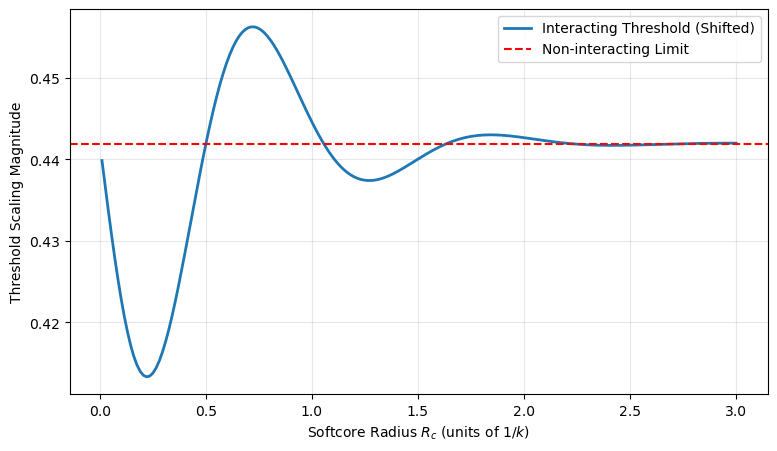

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --- Parameters ---
nz = 0.8          # Spin polarization
omega = 1.0       # Transition frequency
omega_R = 0.1     # Recoil frequency
tc = 2.0          # Thermal coherence time (m*beta/k^2)^0.5
V0 = 0.2          # Interaction strength (Repulsive V0 > 0)
k_cav = 2 * np.pi # Cavity wavevector (normalized units)

def chi0_func(t, nz, w, wR, tc):
    envelope = np.exp(-t**2 / (2 * tc**2))
    return envelope * (np.sin((w - wR)*t)*(nz + 1) + np.sin((w + wR)*t)*(nz - 1))

def get_Vk_analytical(k, V0, Rc):
    """Analytical 1D Fourier Transform of V0/(1+(r/Rc)^6)"""
    term1 = np.exp(-k * Rc)
    term2 = 2 * np.exp(-k * Rc / 2) * np.cos(np.sqrt(3)/2 * k * Rc - np.pi/3)
    return (np.pi * V0 * Rc / 3) * (term1 + term2)

# 1. Compute static chi0
chi0_val, _ = quad(chi0_func, 0, 10*tc, args=(nz, omega, omega_R, tc))

# 2. Sweep Rc
Rc_range = np.linspace(0.01, 3.0, 200)
rhs_vals = []

for Rc in Rc_range:
    Vk = get_Vk_analytical(k_cav, V0, Rc)
    # The RHS: [1/chi0 - 0.5 * V(k)]
    val = (1.0 / chi0_val) - 0.5 * Vk
    rhs_vals.append(val)

# --- Plot ---
plt.figure(figsize=(9, 5))
plt.plot(Rc_range, np.abs(rhs_vals), lw=2, label='Interacting Threshold (Shifted)')
plt.axhline(y=np.abs(1/chi0_val), color='r', ls='--', label='Non-interacting Limit')
plt.xlabel(r'Softcore Radius $R_c$ (units of $1/k$)')
plt.ylabel('Threshold Scaling Magnitude')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()